In [ ]:
# Numpy and Pandas
import pandas as pd
import numpy as np

# Matplotlib and Seaborn
import matplotlib.pyplot as plt
from matplotlib import colormaps 
import seaborn as sns

# Science-kit learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Others
from imblearn.under_sampling import RandomUnderSampler
from scipy.stats import chi2_contingency
from collections import Counter

import itertools
import kagglehub
import random
import math
from sympy import im

# 2. DATASET OBTENTION

In [31]:
# Download latest version
path = kagglehub.dataset_download("anjalibhegam/multimodal-sports-injury-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\vicfo\.cache\kagglehub\datasets\anjalibhegam\multimodal-sports-injury-dataset\versions\2


In [88]:
# Initial inspection
with open("multimodal_sports_injury_dataset.csv") as dataset:
    df = pd.read_csv(dataset)
df 

,athlete_id,heart_rate,body_temperature,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,joint_angles,gait_speed,...,training_intensity,training_duration,training_load,fatigue_index,injury_occurred,session_id,sport_type,gender,age,bmi
0,1,NaN,37.048668,76.481477,5.466370,77.899691,0.375825,10.000000,126.480118,2.654327,...,5.678475,79.106564,548.417962,45.028687,0,1,Basketball,Female,18,25.105748
1,1,40.000000,36.929536,72.363938,6.899090,74.845323,0.279165,310.293156,157.631630,3.431107,...,NaN,116.954654,538.043815,42.254717,2,2,Basketball,Female,18,25.105748
2,1,76.174609,36.334841,100.000000,9.574152,83.538316,0.334061,158.659094,81.766287,0.800000,...,6.643242,96.354742,647.784339,61.870056,0,3,Basketball,Female,18,25.105748
3,1,100.543724,37.244474,86.172473,7.614297,79.966618,0.218766,107.079298,113.023701,1.713869,...,6.194427,97.619130,336.553431,50.268845,0,4,Basketball,Female,18,25.105748
4,1,78.001235,36.510766,83.195889,5.631979,56.945979,0.484086,164.347133,112.814695,2.154233,...,5.835804,83.155527,496.076352,29.233575,2,5,Basketball,Female,18,25.105748
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15415,84,69.956860,37.214621,69.544088,4.418336,38.957484,0.239706,NaN,127.835085,NaN,...,7.038863,63.341808,627.752431,52.845054,0,100,Basketball,Female,26,20.145185
15416,18,70.785554,36.927019,84.422453,3.976723,34.893546,0.472006,263.783492,128.887289,NaN,...,5.504547,81.735077,1001.613854,67.373233,2,100,Track,Female,24,21.309957
15417,141,108.757968,36.875496,76.679104,4.552625,39.487996,0.628583,333.898593,157.497212,2.176849,...,7.794103,106.064377,767.130093,76.089216,1,100,Basketball,Male,23,28.098897
15418,113,65.489580,37.343535,60.761053,3.877293,39.956892,0.664920,320.438215,123.040641,2.342617,...,5.703675,108.543899,793.033403,76.804070,0,99,Track,Female,34,22.719505


## 2.1 Dataset initial inspection

In [89]:
# Nullity and data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   athlete_id             15420 non-null  int64  
 1   heart_rate             15066 non-null  float64
 2   body_temperature       15420 non-null  float64
 3   hydration_level        15035 non-null  float64
 4   sleep_quality          14927 non-null  float64
 5   recovery_score         15420 non-null  float64
 6   stress_level           15420 non-null  float64
 7   muscle_activity        14850 non-null  float64
 8   joint_angles           15420 non-null  float64
 9   gait_speed             14989 non-null  float64
 10  cadence                15420 non-null  float64
 11  step_count             15420 non-null  int64  
 12  jump_height            15420 non-null  float64
 13  ground_reaction_force  15420 non-null  float64
 14  range_of_motion        15420 non-null  float64
 15  am

In [90]:
# Basic statistics
cols_no_stats = ["athlete_id", "playing_surface", "injury_occurred", "session_id"] # Columns which would make no sense to study basic statistics from
df.drop(columns = cols_no_stats).describe(exclude = object) # Exclude columns whose data type is "object"

,heart_rate,body_temperature,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,joint_angles,gait_speed,cadence,...,range_of_motion,ambient_temperature,humidity,altitude,training_intensity,training_duration,training_load,fatigue_index,age,bmi
count,15066.000000,15420.000000,15035.000000,14927.000000,15420.000000,15420.000000,14850.000000,15420.000000,14989.000000,15420.000000,...,15420.000000,15420.000000,15420.000000,15420.000000,14788.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,72.688277,37.106443,78.036991,5.817429,55.202220,0.422916,247.724105,112.464607,1.864699,86.803006,...,124.794439,24.898073,58.191697,297.357416,6.399174,87.790419,670.534269,59.698315,23.953567,23.138679
std,17.758991,0.594843,11.848363,1.814602,17.326338,0.173425,126.930007,30.367148,0.603927,24.296357,...,24.529425,5.095228,13.526094,212.351977,1.730882,27.628191,328.288466,25.196238,3.883533,2.301192
min,40.000000,35.800000,45.000000,1.155807,8.902584,0.100000,10.000000,45.000000,0.800000,50.000000,...,60.000000,15.000000,30.000000,0.000000,2.000000,30.000000,150.000000,15.000000,18.000000,18.500000
25%,60.097967,36.698612,69.879145,4.510581,42.321722,0.300472,159.150375,91.437246,1.430372,68.051911,...,108.353902,21.254558,48.605990,127.750679,5.208488,68.768634,426.148857,41.717110,21.000000,21.609635
50%,72.304051,37.107090,78.165927,5.755650,54.421403,0.421168,245.496682,112.548535,1.854269,85.716003,...,124.572536,24.839380,58.206251,284.172663,6.411926,87.835380,645.225337,57.340187,24.000000,22.988013
75%,84.812895,37.512165,86.498440,7.068894,67.375690,0.543678,334.039698,133.960070,2.281691,103.378064,...,141.738414,28.397207,67.872637,442.388486,7.597567,106.696365,879.607967,75.186924,27.000000,24.817666
max,159.270125,39.200000,100.000000,10.000000,98.000000,0.950000,722.542819,175.000000,3.500000,185.943983,...,180.000000,38.000000,85.000000,1200.000000,10.000000,180.000000,2632.637547,270.193219,34.000000,28.300000


In [91]:
# Groups %s

# Counts per target group
labels_counts = Counter(df["injury_occurred"])
keys = list(labels_counts.keys())
vals = list(labels_counts.values())
n_labels = len(df["injury_occurred"])

# Show the results
for i in range(len(labels_counts)):
    lbl = keys[i]
    count = vals[i]
    print(f"Label {lbl} represents the {round(count/n_labels*100, 3)}% of the dataset.")

Label 0 represents the 63.995% of the dataset.
Label 2 represents the 15.006% of the dataset.
Label 1 represents the 20.999% of the dataset.


# 3. DATA CLEANING

## 3.1 Missing values (NAs)

In [92]:
print(15*"=" +  " Missing values (NAs) " + 15*"=")

# ========================== TOTAL in the dataset ==========================
na_total = (df.isnull().sum().sum() / df.size) * 100
print(f"- Total: {round(na_total, 3)}%")

# =============================== by FEATURE ===============================
n = 7 # Number of top features to be displayed
na_feature = (df.isnull().mean() * 100).sort_values(ascending = False)
print(f"\n- By feature (top {n}):")
print(na_feature.head(n))

# ============================= by TARGET CLASS ============================
na_class = df.groupby('injury_occurred').apply(
    lambda x: x.isnull().mean().mean() * 100, 
    include_groups = False
)
print("\n - By class:")
print(na_class)

# Test significance between classes:

    # Divide by groups and then drop the NAs of each group
healthy = df[df["injury_occurred"]==0];  h_data = healthy.dropna();  
low     = df[df["injury_occurred"]==1];  l_data = low.dropna();  
inj     = df[df["injury_occurred"]==2];  i_data = inj.dropna()

    # Create the Chi-Square table as Present/Missing vs Healthy/LowRisj/Injuried
table = [
    [len(h_data), len(healthy) - len(h_data)],  
    [len(l_data), len(low)     - len(l_data)],  
    [len(i_data), len(inj)     - len(i_data)]
]

chi2, p, dof, expected = chi2_contingency(table)
print(f"\nChi-Square p-value: {round(p,4)}")

# =============================== DROP NAs ==============================
df.dropna(inplace = True)

=============== Missing values (NAs) ===============
- Total: 0.641%

- By feature (top 7):
training_intensity    4.098573
muscle_activity       3.696498
sleep_quality         3.197147
gait_speed            2.795071
hydration_level       2.496757
heart_rate            2.295720
body_temperature      0.000000
dtype: float64

 - By class:
injury_occurred
0    0.654714
1    0.658475
2    0.708421
dtype: float64

Chi-Square p-value: 0.6726


## 3.2 Duplicated data

In [93]:
# Remove duplicates (exact matches between rows considering all columns)
n_dups = Counter(df.duplicated())[True]
df.drop_duplicates(inplace = True)
print(f"Removed {n_dups} rows. ")

Removed 0 rows. 


## 3.3 Integer encoding: strings to numeric data

In [94]:
# Numeric equivalences
sports = {"Basketball": 0, 
          "Soccer"    : 1, 
          "Track"     : 2,
          "Other"     : 3}

genders = {"Male"  : 0, 
           "Female": 1}

labels_change = {
    0: 0,
    1: 0,
    2: 1
}

# Transoform both columns
df['sport_type'] = df['sport_type'].map(sports)
df['gender']     = df['gender']    .map(genders)

# Conversion from 3 labels to 2 labels. Return here after finishing the analysis. 
# df['injury_occurred']     = df['injury_occurred']    .map(labels_change)

# 4. DATA INSPECTION

### 4.1 Feature Distributions

##### 4.1.1 Visualize all features

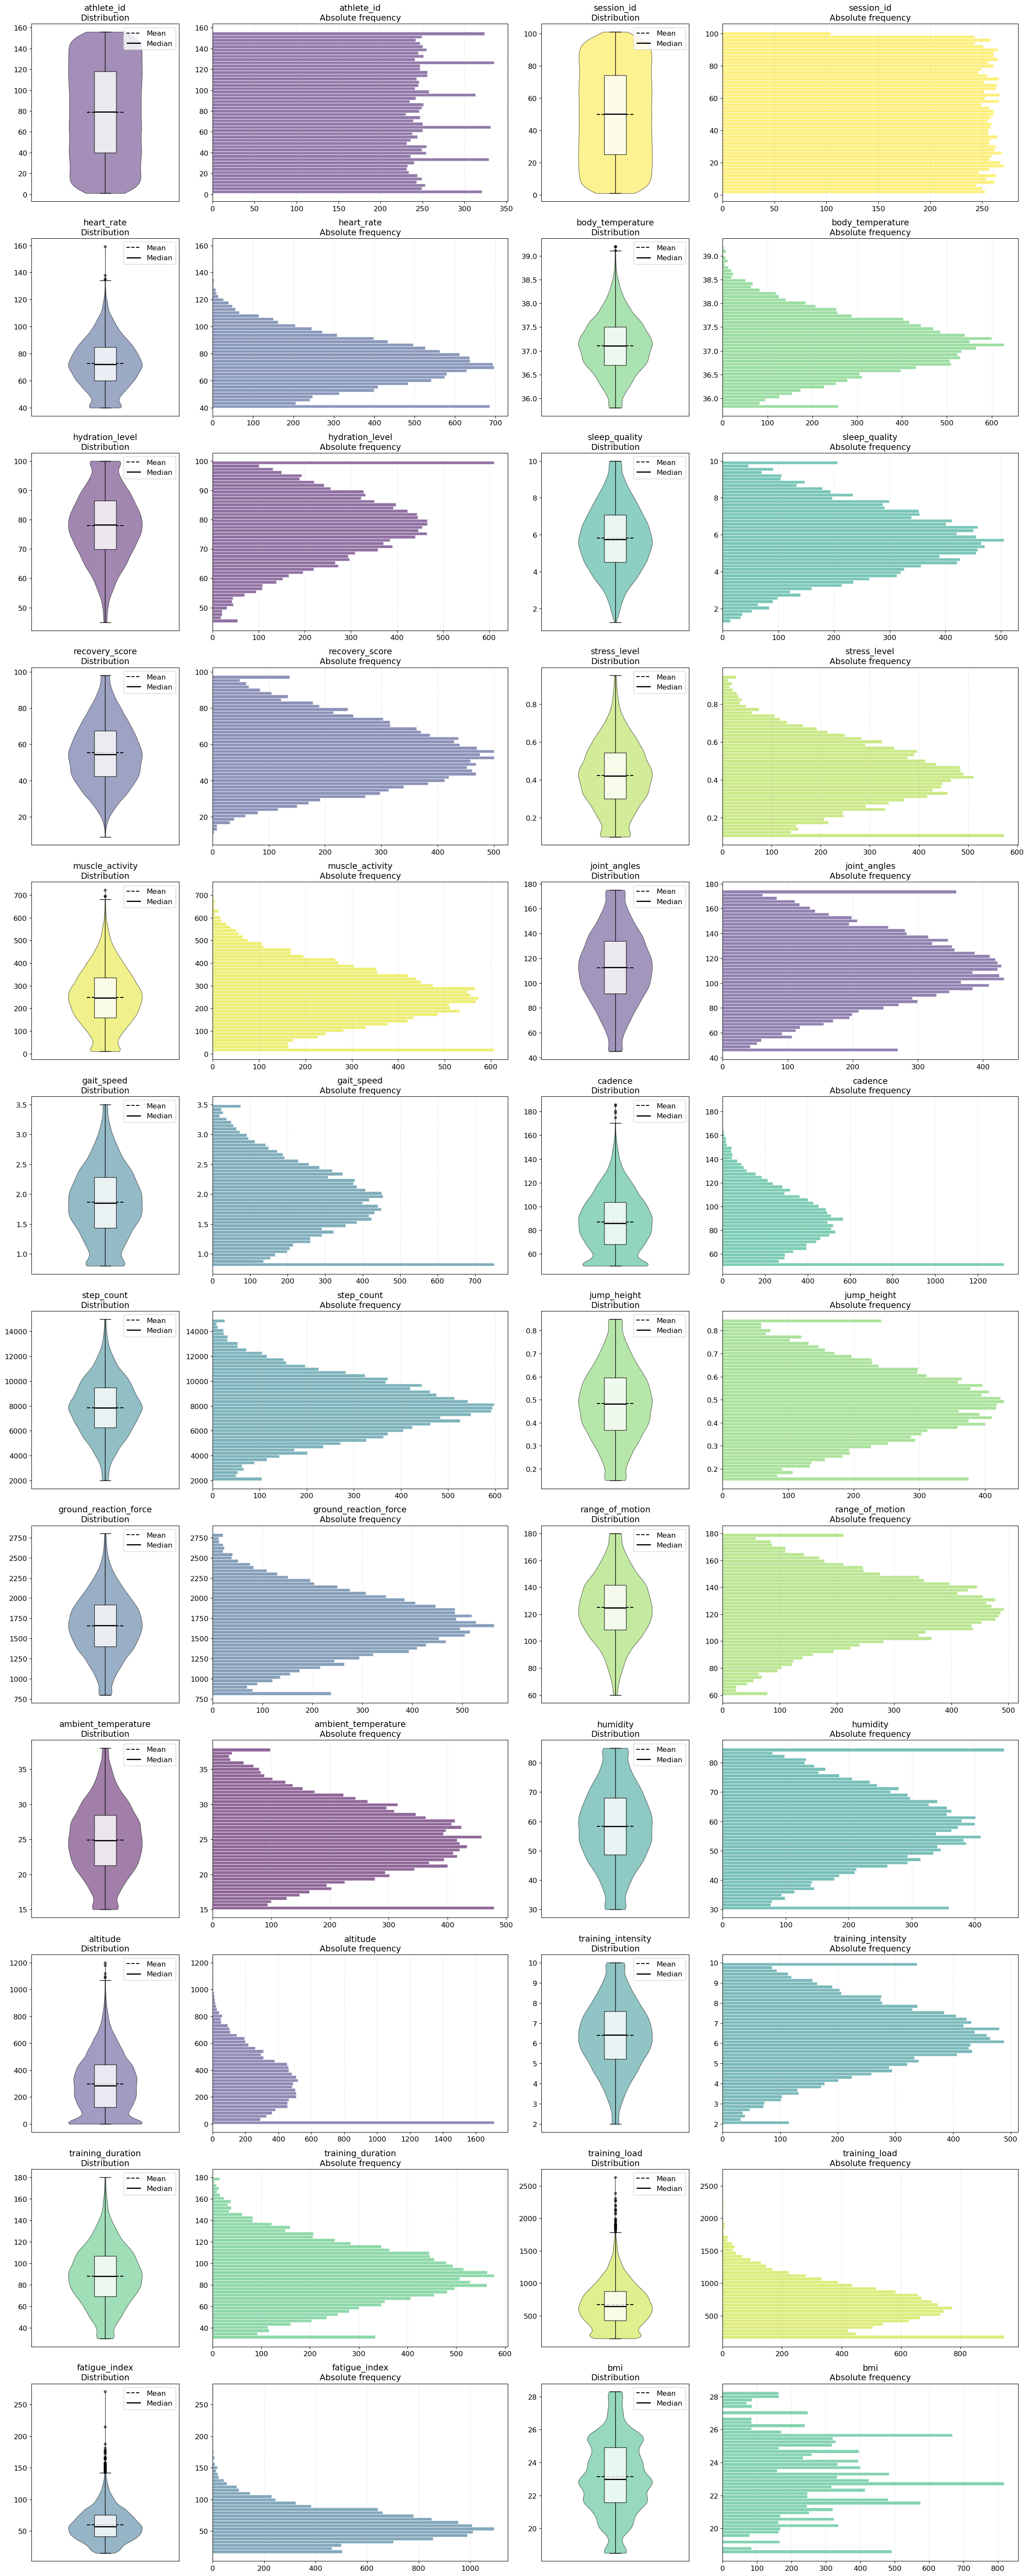

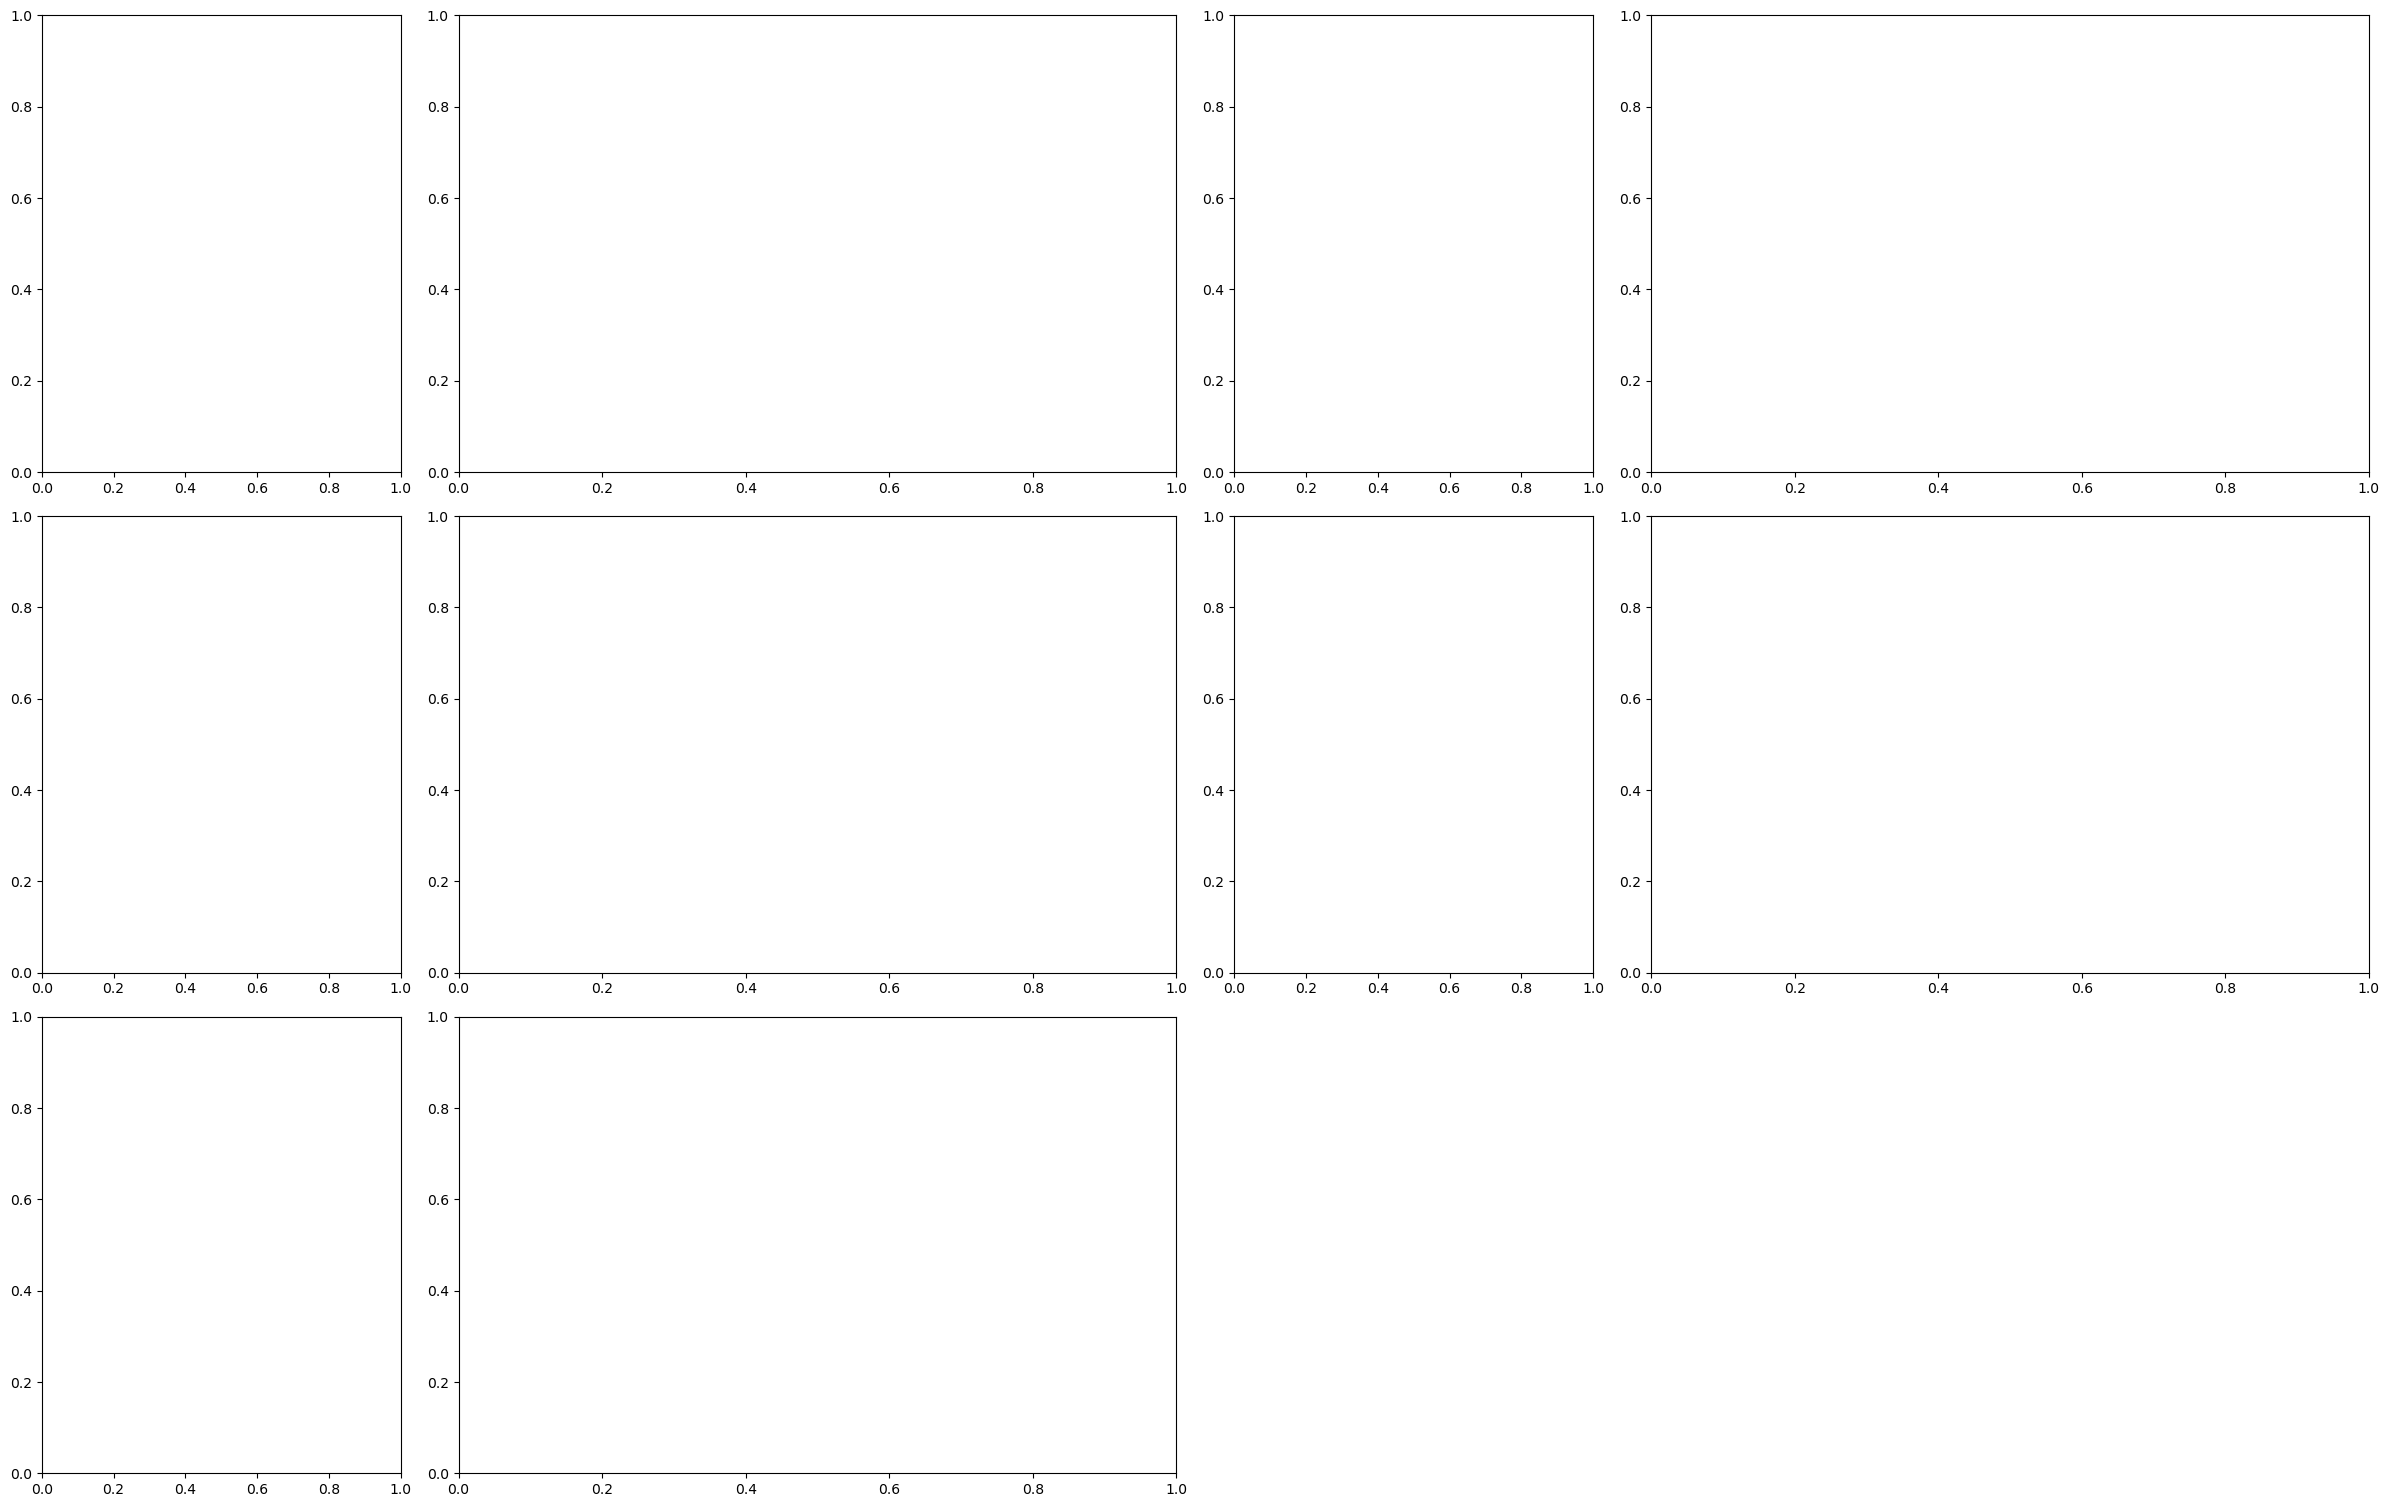

In [ ]:
# General plot configuration
plots_per_page = 24
cols = 2
rows = math.ceil(plots_per_page / cols)

# Sort columns in the specific desired order
ids = ["athlete_id", "session_id"]
numeric_cols = [c for c in df.columns if df[c].dtype == float or c in ("step_count")]
all_numeric_cols = ids + numeric_cols
categorical_cols = [c for c in df.columns if c not in all_numeric_cols]
sorted_columns = ids + numeric_cols + categorical_cols

# High-contrast color palette
cmap = colormaps.get_cmap("viridis") 
color_list = [cmap(i) for i in np.linspace(0, 1, len(all_numeric_cols))] # A color for every plot
random.seed(12) 
random.shuffle(color_list) 


# Iterarte over each feature (by their indexes)
for i in range(0, len(sorted_columns), 
               plots_per_page # 6 by 6
              ):

    # Chunk of features
    chunk = sorted_columns[i : i + plots_per_page]
    
    # Initialize 6-composed-plots figure
    fig, axes_grid = plt.subplots(rows, cols * 2, 
                                  figsize=(24, 5 * rows), 
                                  gridspec_kw={"width_ratios": [1, 2] * cols}) # Space distribution for subplots
    axes_flat = axes_grid.flatten()

    # Iterate over each feature of the chunk to define its axes
    for indx, fture in enumerate(chunk):
        data = df[fture]
        ax_left =axes_flat[indx * 2] 
        ax_right = axes_flat[indx * 2 + 1]

        if fture in all_numeric_cols:
            ax_right.sharey(ax_left)
            
            # Select the color
            feature_indx = all_numeric_cols.index(fture)
            current_color = color_list[feature_indx]
            
            # ======= Left side plot: Violin + Box =======
            violin_parts = ax_left.violinplot(data, 
                               vert        = True, 
                               showmeans   = True,
                               showextrema = False)
            
            # Coloring using our high-contrast current_color
            for v_p in violin_parts["bodies"]:
                v_p.set_facecolor(current_color) 
                v_p.set_edgecolor("black")    
                v_p.set_alpha(0.5)

            # Stylish mean line
            violin_parts["cmeans"].set_color("black")
            violin_parts["cmeans"].set_linestyle('--') # Dashed    

            ax_left.tick_params(axis="y", which='major', labelsize=12)

            # Overlaying the boxplot
            box_parts = ax_left.boxplot(data, 
                                whis = 2, # Little increase with respect to default = 1.5, because extreme values are expected in these features
                                positions = [1], # To join Box with Violin
                                widths = 0.15, 
                                patch_artist = True,
                                boxprops    = dict(facecolor = "white", color = "black", alpha = 0.8),
                                medianprops = dict(color = "red", linewidth = 2),
                                flierprops  = dict(marker = "o", markerfacecolor = "black", markersize = 4, alpha = 0.5))
            
            ax_left.set_title(f"{fture}\nDistribution", fontsize=14)
            ax_left.set_xticks([]) # No sense having them in this plot
            box_parts["medians"][0].set_color("black")

            # Legend
            violin_parts["cmeans"].set_label("Mean")
            box_parts["medians"][0].set_label("Median")
            ax_left.legend(loc = "upper right", fontsize = 12, frameon = True)
        
            # ======= Right side plot: Histogram =======
            ax_right.hist(data, 
                         bins = 50, 
                         orientation = "horizontal", 
                         color = current_color, 
                         edgecolor = "white", 
                         alpha = 0.6)
            
            ax_right.set_title(f"{fture}\nAbsolute frequency", fontsize = 14)
            ax_right.tick_params(axis='both', which='major', labelsize=12)
            ax_right.grid(axis = "x", linestyle = "--", alpha = 0.3)

    # Hide unused axis
    used_axes = len(chunk) * 2
    for j in range(used_axes, len(axes_flat)):
        axes_flat[j].set_visible(False)
    
    plt.show()      
    plt.close(fig)

##### 4.1.2 Visualize specific features

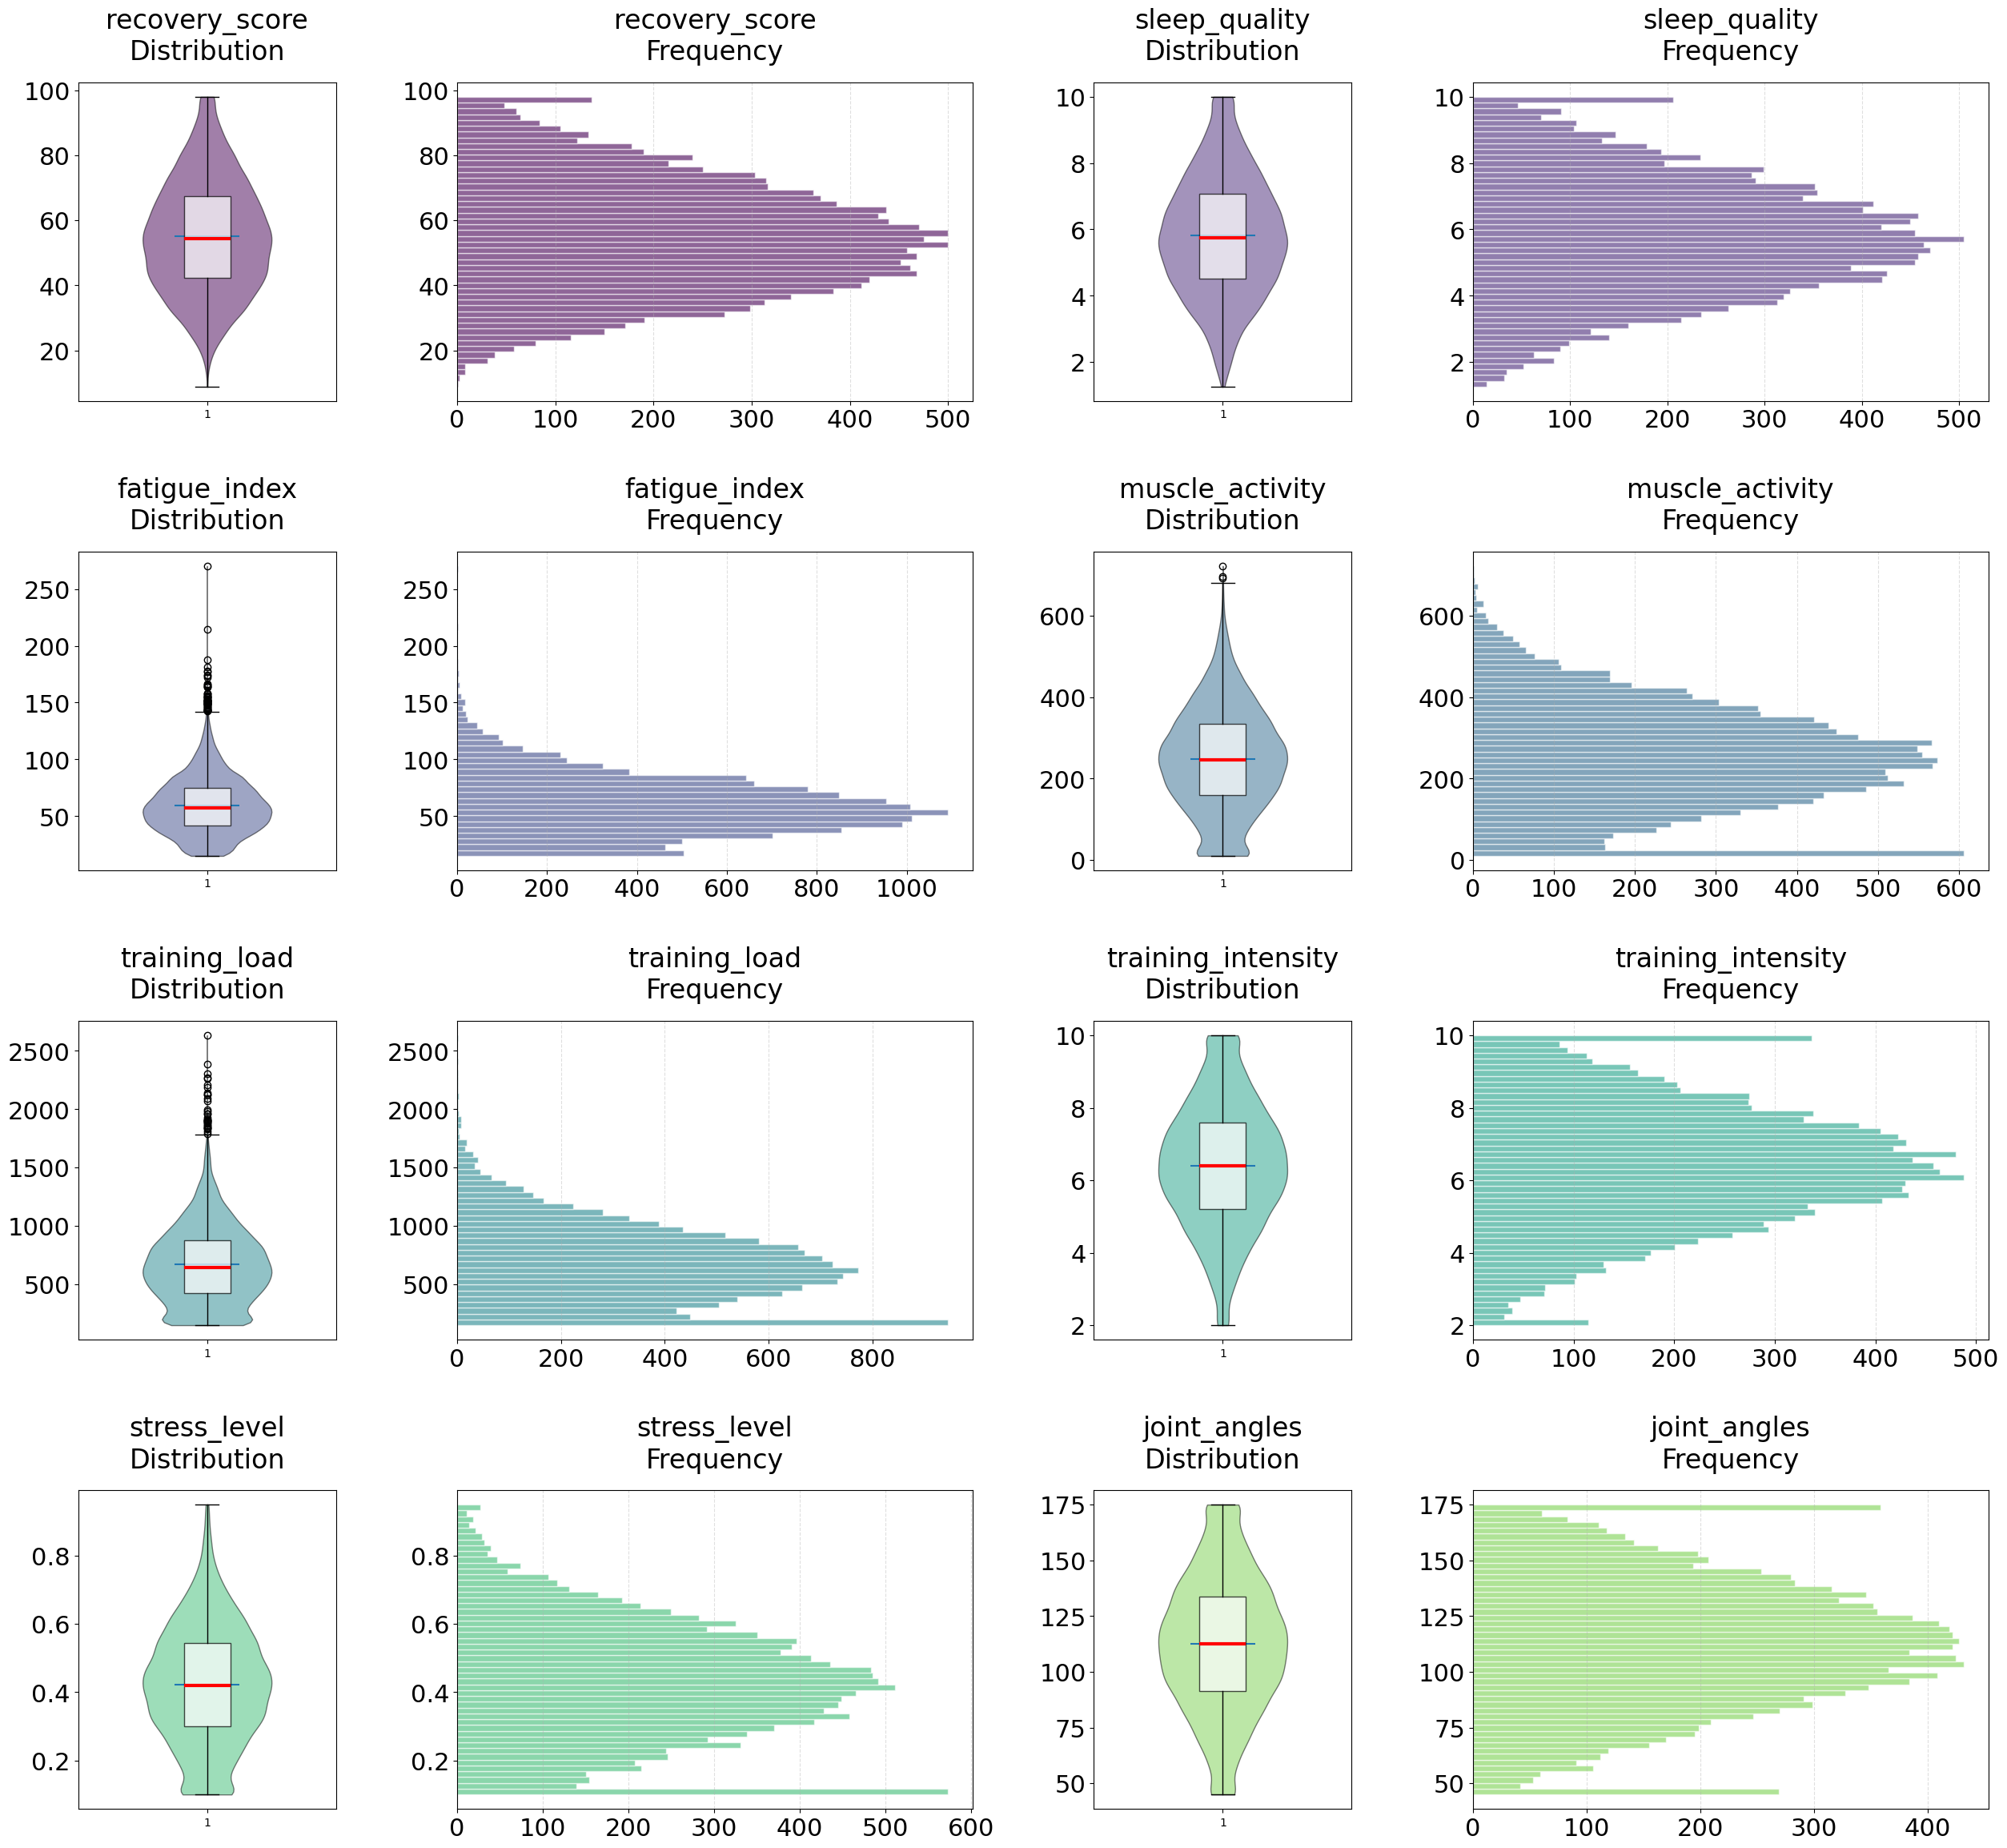

In [70]:
# List of features
features_to_plot = ["recovery_score", "sleep_quality", "fatigue_index", "muscle_activity", "training_load", "training_intensity", "stress_level", "joint_angles"] 

# Config
cols = 2
rows = math.ceil(len(features_to_plot) / cols)
plots_per_row = cols * 2 
cmap = colormaps.get_cmap("viridis")
colors = [cmap(i) for i in np.linspace(0, 0.8, len(features_to_plot))]

# Initialize Figure
fig, axes_grid = plt.subplots(rows, plots_per_row, 
                              figsize=(26, 6 * rows), 
                              gridspec_kw={"width_ratios": [1, 2] * cols})
axes_flat = axes_grid.flatten()

# Iterate over the feature list
for indx, fture in enumerate(features_to_plot):
    data = df[fture].dropna() 
    ax_left = axes_flat[indx * 2] 
    ax_right = axes_flat[indx * 2 + 1]
    current_color = colors[indx]

    # Shared Y-axis
    ax_right.sharey(ax_left)
    
    # ======= Left side plot: Violin + Box =======
    violin_parts = ax_left.violinplot(data, vert=True, showmeans=True, showextrema=False)
    
    for v_p in violin_parts["bodies"]:
        v_p.set_facecolor(current_color) 
        v_p.set_edgecolor("black")    
        v_p.set_alpha(0.5) # Reduced alpha (~0.2 less than previous 0.7)

    # Style ticks for better visualization
    ax_left.tick_params(axis="y", labelsize=22)
    ax_left.set_xticks([]) 

    box_parts = ax_left.boxplot(data, whis=2, positions=[1], widths=0.18, 
                                patch_artist=True,
                                boxprops=dict(facecolor="white", color="black", alpha=0.7),
                                medianprops=dict(color="red", linewidth=3))
    
    # Aligned titles
    ax_left.set_title(f"{fture}\nDistribution", fontsize=24, fontweight='normal', y=1.05)

    # ======= Right side plot: Histogram =======
    ax_right.hist(data, bins=50, orientation="horizontal", 
                  color=current_color, edgecolor="white", alpha=0.6) # Reduced alpha
    
    ax_right.set_title(f"{fture}\nFrequency", fontsize=24, fontweight='normal', y=1.05)
    
    # Big ticks for visualization
    ax_right.tick_params(axis='both', which='major', labelsize=22)
    ax_right.grid(axis="x", linestyle="--", alpha=0.4)

# Hide unused axes
used_slots = len(features_to_plot) * 2
for j in range(used_slots, len(axes_flat)):
    axes_flat[j].set_visible(False)

# Save in SVG and show the plot
plt.tight_layout(pad=4.0)
plt.savefig("feature_distributions_clean.svg", format="svg", bbox_inches='tight')
plt.show()

### 4.2 Feature Correlations

In [17]:
# Filter out features that are not numeric and continuous
cols_no_corrs = ["athlete_id", "playing_surface", "injury_occurred", "session_id", "gender", "sport_type"] 
df_corrs = df.copy()
df_corrs.drop(columns = cols_no_corrs, inplace = True) # Exclude columns whose data type is "object"

# Function to generate a True/False matrix of correlation significance
def corr_filter(data, sig):
    filtered_data = (data.abs() > sig) & (data != 1.0)
    return filtered_data
    
# Initial correlation calculation between all variables
corrs = df_corrs.corr(numeric_only = True) 

# Filter out correlations with an absolute value lower than the "sig" and with 1 (same variable)
true_false_corr = corr_filter(corrs, 0.5)
sig_corr = corrs[true_false_corr] 

# Rows/cols that have at least one True value
to_keep = true_false_corr.any()
filt_cor = corrs.loc[to_keep, to_keep]
filt_cor_filt = filt_cor[corr_filter(filt_cor, 0.5)]

# Display it
filt_cor_filt

,sleep_quality,recovery_score,stress_level,training_intensity,training_duration,training_load,fatigue_index
sleep_quality,NaN,0.773212,-0.506722,NaN,NaN,NaN,NaN
recovery_score,0.773212,NaN,NaN,NaN,NaN,NaN,NaN
stress_level,-0.506722,NaN,NaN,NaN,NaN,NaN,NaN
training_intensity,NaN,NaN,NaN,NaN,0.595282,0.788174,0.592522
training_duration,NaN,NaN,NaN,0.595282,NaN,0.698377,NaN
training_load,NaN,NaN,NaN,0.788174,0.698377,NaN,0.803953
fatigue_index,NaN,NaN,NaN,0.592522,NaN,0.803953,NaN


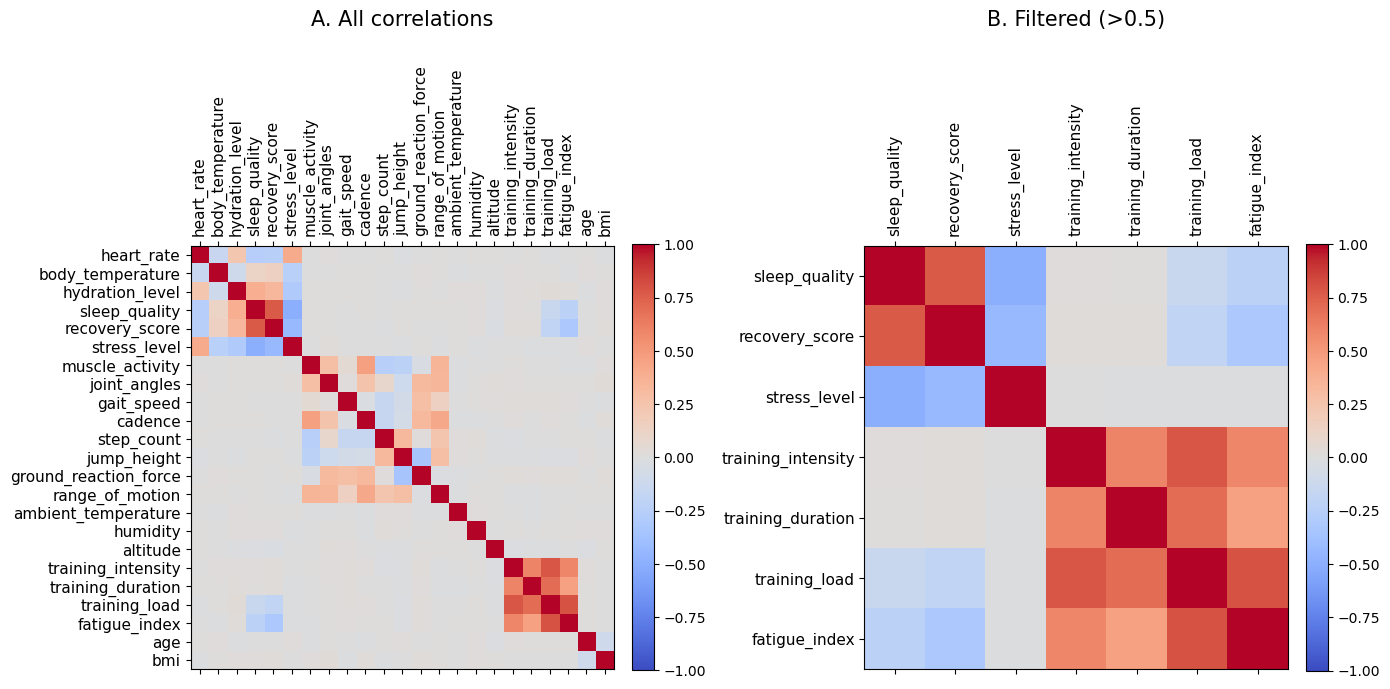

In [29]:
# Plot correlations
fig, axes = plt.subplots(1, 2, figsize=(14, 7)) # Slightly wider to accommodate labels

def plot_matrix(ax, matrix, title):
    im = ax.matshow(matrix, cmap="coolwarm", vmin=-1, vmax=1)
    labels = matrix.columns
    
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation="vertical", size=11)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, size=11)
    
    # This forces both titles to the same height regardless of label length
    ax.set_title(title, y=1.5, fontsize=15)
    
    color_bar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    color_bar.ax.tick_params(labelsize=10)

# Plotting
plot_matrix(axes[0], corrs, "A. All correlations")
plot_matrix(axes[1], filt_cor, "B. Filtered (>0.5)")

# Note: tight_layout sometimes struggles with matshow top-labels. 
# Using rect helps reserve space at the top for the titles.
plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.savefig("correlations_plot.png", format="png", bbox_inches='tight')
plt.show()

# 5. CLASSIFICATION ANALYSIS WITH MACHINE LEARNING

## 5.1 Data tuning

#### 5.1.1 Data splitting

In [95]:
# Split on X (samples) and Y (labels)
data = df.copy()
data.drop(columns = "injury_occurred", inplace = True)
labels = df["injury_occurred"]

In [96]:
# Split on training and testing subdatasets
data_train, data_test, labels_train, labels_test = train_test_split(
    data, 
    labels,
    test_size = 0.25, # 75% Training and 25% Testing
    random_state = 42) 

#### 5.1.2 Downsampling majority classes

In [97]:
# Initialize the sampler
und_sampl = RandomUnderSampler(sampling_strategy = "not minority", # Downsample everything except the smallest class
                               random_state = 42) # Replacement = False, by default

# Resample training data (not testing data, to keep the original distribution of target groups)
data_train, labels_train = und_sampl.fit_resample(data_train, labels_train)

print(f"Downsampled distribution: {Counter(labels_train)}")

Downsampled distribution: Counter({0: 1430, 1: 1430, 2: 1430})


#### 5.1.2 Normalization (standard)

In [98]:
# Initialize 
std_scaler = StandardScaler()

# Standard normalization (to the mean, divided by standard deviation)
data_train[numeric_cols] = std_scaler.fit_transform(data_train[numeric_cols]) # Fit_transform in training data to use its mean/sigma
data_test[numeric_cols] = std_scaler.transform(data_test[numeric_cols]) # Only transform, to avoid data leakage

## 5.2 Random Forest

#### 5.2.1 Feature Selection

In [99]:
# Feature selector
selector = RFE(RandomForestClassifier(n_estimators = 100, 
                                      random_state = 42), 
                                      n_features_to_select = 15, 
                                      step = 1)
selector = selector.fit(data_train, labels_train)

# Filter out non-selected features
data_train = data_train.loc[:, selector.support_]
data_test = data_test.loc[:, selector.support_]

# Show the selected features
print(f"Features kept: {data_train.columns.tolist()}.\n{len(data_train.columns.tolist())} in total.")

Features kept: ['heart_rate', 'body_temperature', 'hydration_level', 'sleep_quality', 'recovery_score', 'stress_level', 'muscle_activity', 'gait_speed', 'step_count', 'ground_reaction_force', 'ambient_temperature', 'training_intensity', 'training_duration', 'training_load', 'fatigue_index'].
15 in total.


#### 5.2.1 Hyperparameter tuning

In [100]:
# Parameter ranges/options
params = {
    'n_estimators': [200, 300, 400], # Number of trees in the forest
    'max_depth': [5, 6, 7], # Maximum number of layers in each tree (depth)
    'min_samples_split': [200, 250, 400], # Nodes should separate min. X samples
    'min_samples_leaf': [100, 150, 200], # Final nodes should separate min. X samples
    'max_features': ['sqrt', 'log2'], # Standard for RF
    'max_samples': [0.3, 0.5, 0.6], # Fraction of data to train each tree
}


# Random Forest definition
rf = RandomForestClassifier(#class_weight = "balanced", # Weights data points inverse proportinally to their label frequency
                            n_jobs = -1, # Use all avaibalble CPUs to calculate individual decision trees (faster) 
                            random_state = 42)
# Hyperparameter tunning through random search
random_search = RandomizedSearchCV(
    rf, 
    param_distributions = params, 
    n_iter = 100,
    cv = 5,
    scoring = "f1_weighted", # Performance metric
    random_state = 42)

random_search.fit(data_train, labels_train)

# Show the best iteration
best_params_rf = random_search.best_params_
best_score_rf = random_search.best_score_
print(f"Best Parameters (RF): {best_params_rf}")
print(f"Best Score (RF): {best_score_rf}")

Best Parameters (RF): {'n_estimators': 300, 'min_samples_split': 200, 'min_samples_leaf': 100, 'max_samples': 0.6, 'max_features': 'sqrt', 'max_depth': 5}
Best Score (RF): 0.4864856855599203


#### 5.2.3 Model training

In [104]:
# Train the model with the tunned parameters
model_rf = RandomForestClassifier(n_estimators = best_params_rf.get('n_estimators'), 
                               min_samples_split = best_params_rf.get('min_samples_split'),
                               min_samples_leaf = best_params_rf.get('min_samples_leaf'),
                               max_samples = best_params_rf.get('max_samples'),
                               max_features = best_params_rf.get('max_features'),
                               max_depth = best_params_rf.get('max_depth'),
                               class_weight = "balanced_subsample",
                               oob_score=True,
                               random_state = 42)
model_rf.fit(data_train, labels_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=5,
                       max_samples=0.6, min_samples_leaf=100,
                       min_samples_split=200, n_estimators=300, oob_score=True,
                       random_state=42)

#### 5.2.4 Model testing

##### With 3 Labels

In [105]:
# Evaluate the model with the test subdataset
labels_pred = model_rf.predict(data_test)
labels_names = ['Healthy', "Low Risk", 'Injured']
print(classification_report(labels_test, labels_pred, target_names=labels_names))

              precision    recall  f1-score   support

     Healthy       0.70      0.33      0.45      2015
    Low Risk       0.25      0.37      0.30       702
     Injured       0.33      0.85      0.47       466

    accuracy                           0.41      3183
   macro avg       0.43      0.51      0.41      3183
weighted avg       0.55      0.41      0.42      3183



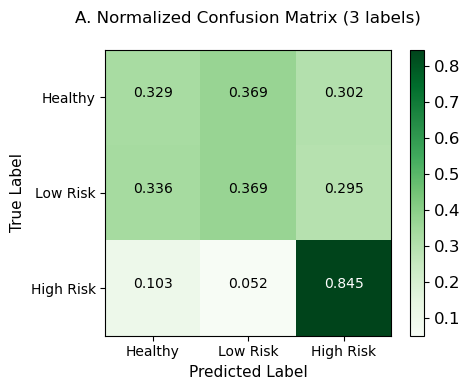

In [103]:
# Representation of the results in a Confussion Matrix
from sympy import im


class_names = ['Healthy', 'Low Risk', 'High Risk']

cm = confusion_matrix(labels_test, # Real y
                      labels_pred) # Predicted y

cm = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis] # Transform absolute values to 0-1 ratios

plt.figure(figsize=(5, 4)) # Bigger axes for visualization
im = plt.imshow(cm, cmap = plt.cm.Greens) # Colormap

plt.title('A. Normalized Confusion Matrix (3 labels)', fontsize=12, pad=20)
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)

plt.xticks([0, 1, 2], class_names, fontsize=10)
plt.yticks([0, 1, 2], class_names, fontsize=10)


# Configure Colorbar
cbar = plt.colorbar(im)
cbar.ax.tick_params(labelsize=12)

# Numbers inside the squares
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], '.3f'), # 2 decimals
             horizontalalignment='center', # Centered
             color='white' if cm[i, j] > 0.5 else 'black') # Color contrast

# Save as SVG
plt.tight_layout()
plt.savefig("confusion_matrix_3labels.svg", format="svg", bbox_inches='tight')
plt.show()

##### With 2 Labels

In [63]:
# Evaluate the model with the test subdataset
labels_pred = model_rf.predict(data_test)
labels_names = ['Healthy/Low Risk(0)', 'Injured(1)']
print(classification_report(labels_test, labels_pred, target_names=labels_names))

                     precision    recall  f1-score   support

Healthy/Low Risk(0)       0.96      0.70      0.81      2717
         Injured(1)       0.32      0.83      0.46       466

           accuracy                           0.72      3183
          macro avg       0.64      0.77      0.64      3183
       weighted avg       0.87      0.72      0.76      3183



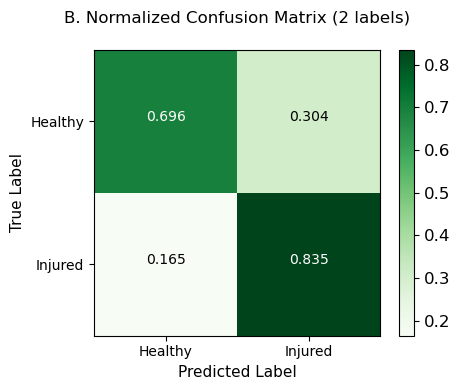

In [67]:
# Representation of the results in a Confussion Matrix
class_names = ['Healthy', 'Injured']

cm = confusion_matrix(labels_test, # Real y
                      labels_pred) # Predicted y

cm = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis] # Transform absolute values to 0-1 ratios

plt.figure(figsize=(5, 4)) # Bigger axes for visualization
im = plt.imshow(cm, cmap = plt.cm.Greens) # Colormap

plt.title('B. Normalized Confusion Matrix (2 labels)', fontsize=12, pad=20)
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)

plt.xticks([0, 1], class_names, fontsize=10)
plt.yticks([0, 1], class_names, fontsize=10)


# Configure Colorbar
cbar = plt.colorbar(im)
cbar.ax.tick_params(labelsize=12)

# Numbers inside the squares
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], '.3f'), # 2 decimals
             horizontalalignment='center', # Centered
             color='white' if cm[i, j] > 0.5 else 'black') # Color contrast

# Save as SVG
plt.tight_layout()
plt.savefig("confusion_matrix_2labels.svg", format="svg", bbox_inches='tight')
plt.show()

# 6. MODEL INTERPRETATION

## 6.1 Importance scores

C:\Users\vicfo\AppData\Local\Temp\ipykernel_13360\3472510862.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_importances, x='Importance', y='Feature', palette=pal, alpha=0.8)


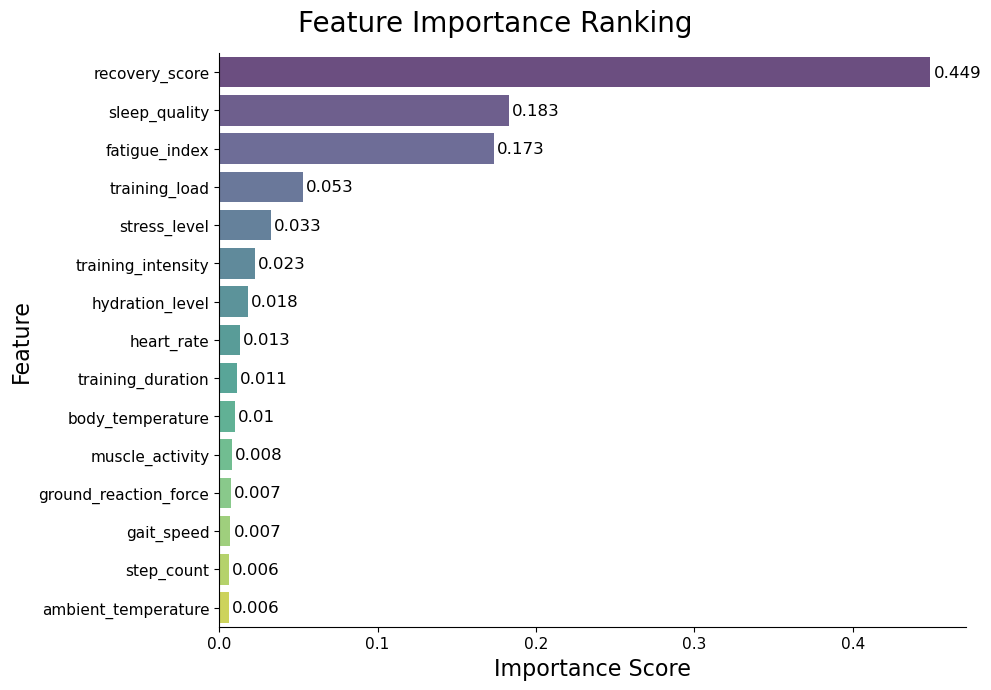

In [118]:
importances = pd.Series(model_rf.feature_importances_, index=data_train.columns).sort_values(ascending=False)
df_importances = importances.reset_index()
df_importances.columns = ['Feature', 'Importance']

plt.figure(figsize=(10, 7))

# barplot with a gradient
pal = sns.color_palette("viridis", len(df_importances))
ax = sns.barplot(data=df_importances, x='Importance', y='Feature', palette=pal, alpha=0.8)

# labels at the end of each bar
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.002,      # x-coordinate (slightly to the right of the bar)
            p.get_y() + p.get_height()/2, # y-coordinate (middle of the bar)
            f'{round(width, 3)}',     # The text (3 decimals)
            va='center', fontsize=12)

# Style ticks and titles
plt.xlabel('Importance Score', fontsize=16)
plt.ylabel('Feature', fontsize=16)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.gcf().suptitle('Feature Importance Ranking', fontsize=20, fontweight='normal', x=0.5)

# Remove the top and right spines
sns.despine()

# 6. Save as SVG
plt.tight_layout()
plt.savefig("feature_importance.svg", format="svg", bbox_inches='tight')
plt.show()

## 6.2 Target groups similarity

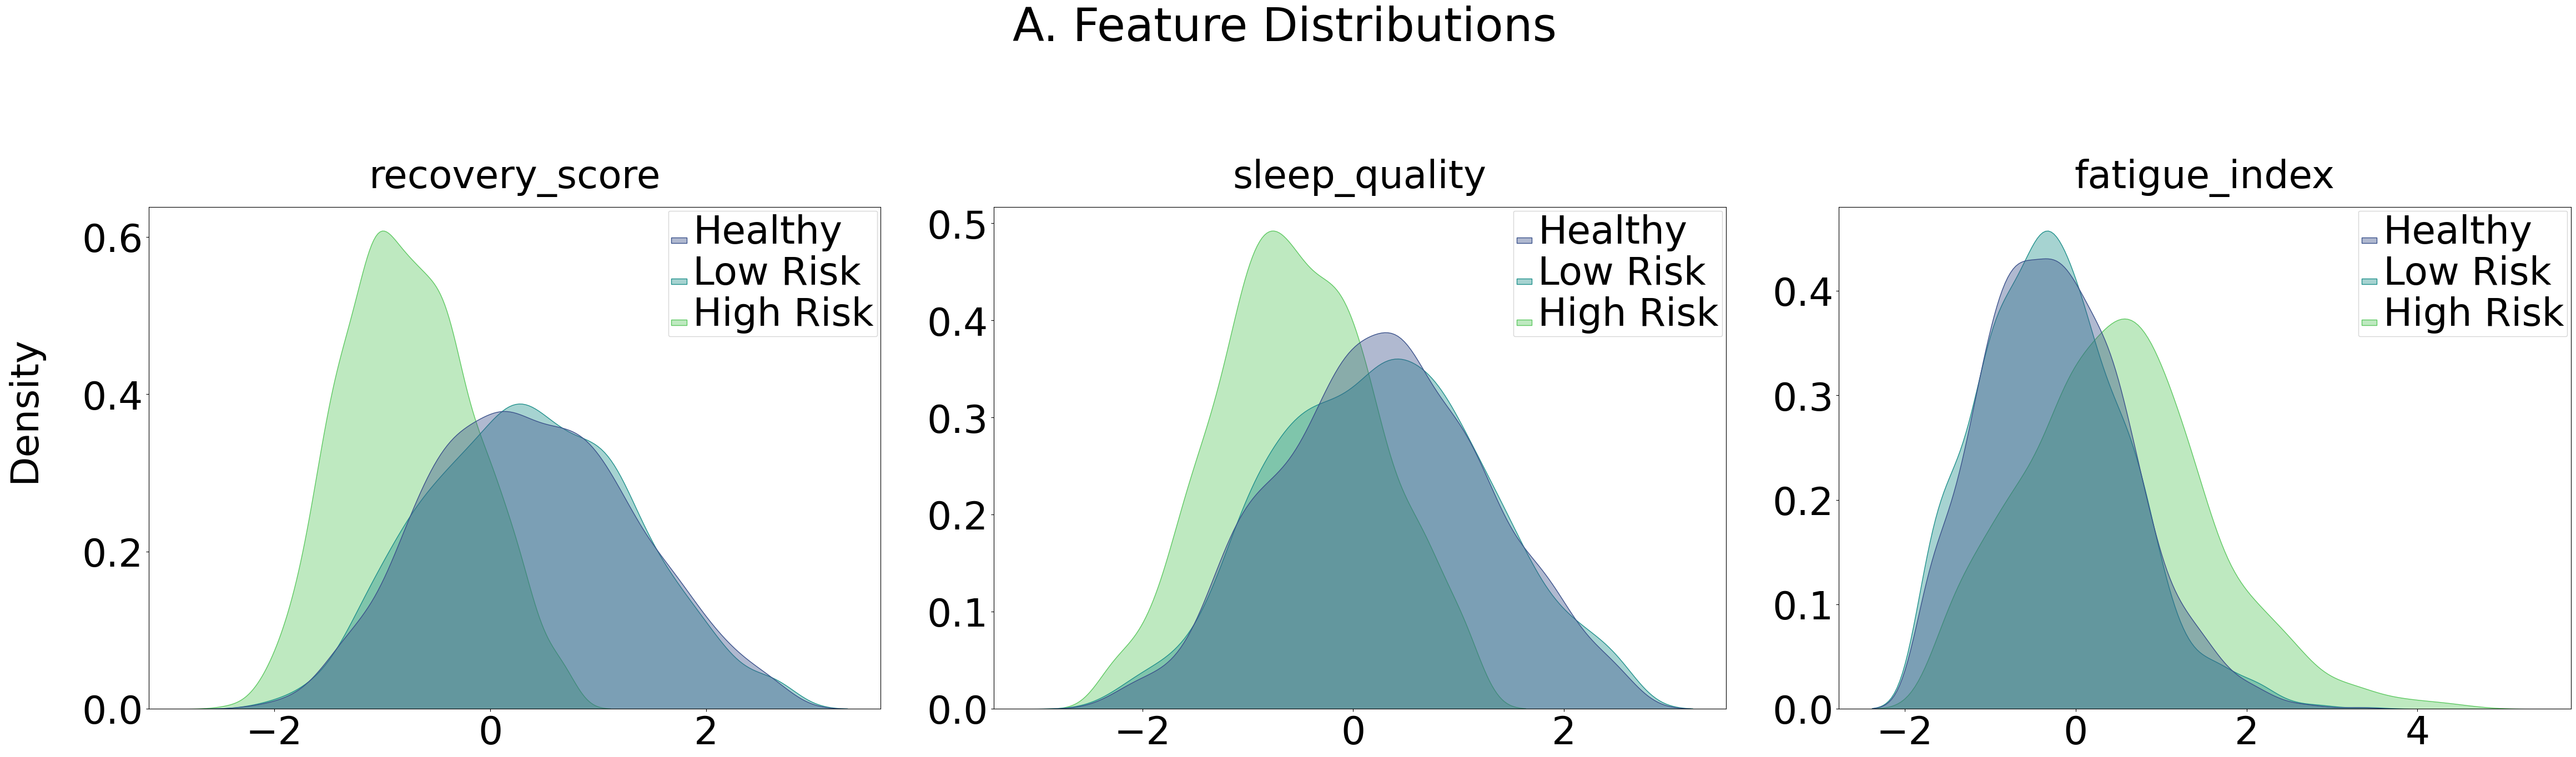

In [158]:
# Data preparation
class_names = {0: 'Healthy', 1: 'Low Risk', 2: 'High Risk'}
plot_data = data_train.copy()
plot_data['Injury_Status'] = labels_train.map(class_names)

# Overlapping features
top_features = importances.sort_values(ascending=False).index[:3]

# gird
cols = 3  
rows = math.ceil(len(top_features) / cols)

# Figure size and axes
fig, axes = plt.subplots(rows, cols, figsize=(cols * 16, rows * 14))
axes_flat = axes.flatten()

# Plot
for i, col in enumerate(top_features):
    ax = axes_flat[i]
    
    sns.kdeplot(data=plot_data, x=col, hue='Injury_Status', fill=True, 
                ax=ax, palette='viridis', alpha=0.4, common_norm=False)
    
    # styling
    ax.set_title(f'{col}', fontsize=50, pad=25, fontweight='normal')
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.tick_params(axis='both', which='major', labelsize=50)
    
    # Legend 
    legend = ax.get_legend()
    legend.set_title(None)
    plt.setp(legend.get_texts(), fontsize='50')

# Hide empty axes
for j in range(len(top_features), len(axes_flat)):
    axes_flat[j].set_visible(False)

# Common Y title for the whole figure
fig.supylabel('Density', fontsize=50, x=0.02)

# Centered title for the whole figure
plt.gcf().suptitle('A. Feature Distributions', 
                   fontsize=60, y=1.02, fontweight='normal')

# Save as svg
plt.tight_layout(pad=6.0)
plt.savefig("density_overlap.svg", format="svg", bbox_inches='tight')
plt.show()

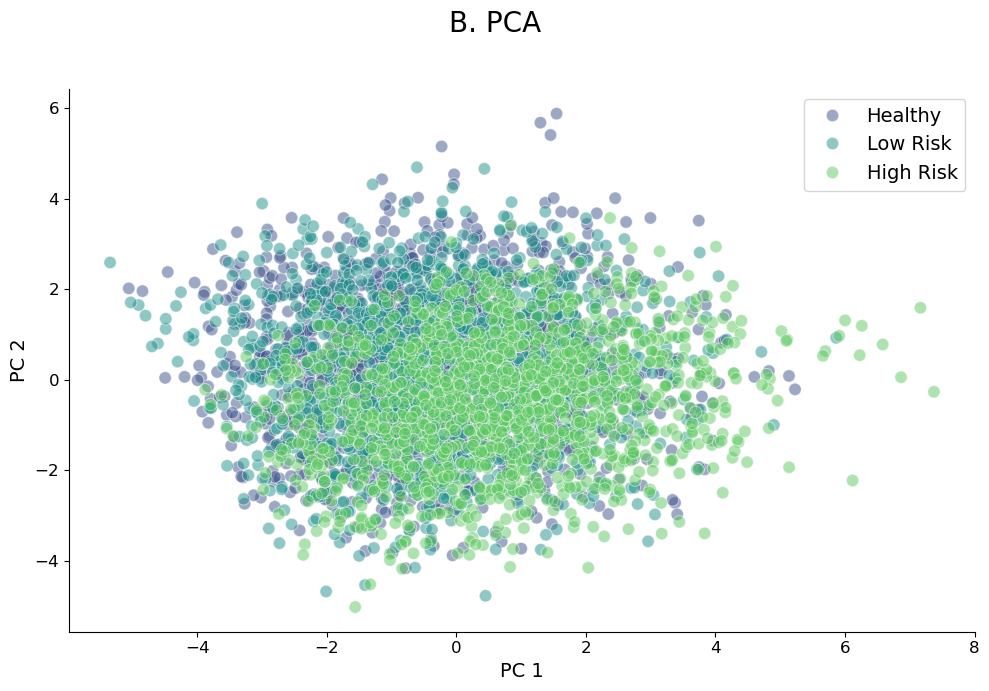

In [150]:
# Prepare PCA and map labels
pca = PCA(n_components=2)
pca_results = pca.fit_transform(data_train)

class_names = {0: 'Healthy', 1: 'Low Risk', 2: 'High Risk'}
labels_mapped = labels_train.map(class_names)

# Figure
plt.figure(figsize=(10, 7))

# PCA Plot
sns.scatterplot(
    x=pca_results[:, 0], 
    y=pca_results[:, 1], 
    hue=labels_mapped, 
    alpha=0.5, 
    palette='viridis',
    edgecolor='w',
    s=80
)

# Style ticks and center title
# We use suptitle to ensure it's centered to the figure canvas
plt.gcf().suptitle(f'B. PCA', 
                   fontsize=20, fontweight='normal', x=0.5, y=0.98)

plt.xlabel('PC 1', fontsize=14)
plt.ylabel('PC 2', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Remove legend title 
legend = plt.legend(fontsize=14, frameon=True)
legend.set_title(None)

sns.despine()

# Save and Show
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("pca.svg", format="svg", bbox_inches='tight')
plt.show()

# 7. REFERENCES